# **Building a CNN: Filters, Layers, Flattening, and Receptive Field**


In [ ]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

import PIL
from PIL import Image, ImageOps
import tensorflow as tf

import glob
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

### Defining Helper Functions


In [2]:
def calc_rf(model):
    # Initialize an array storing all the layers' receptive field sizes and set layer 0 (input) RF to 1
    num_layers = len(model.layers)
    rf_arr = np.empty(num_layers+1, dtype=int)
    rf_arr[0] = 1
    # Initialize an array storing all the layers' jump sizes and set layer 0 (input) jump to 1
    j_arr = np.empty(num_layers+1, dtype=int)
    j_arr[0] = 1
    
    for i in range(num_layers):
        layer = model.layers[i]
        k = layer.kernel_size[0]
        s = layer.strides[0]
        j_in = j_arr[i]
        j_out = j_in * s
        r_out = rf_arr[i] + (k - 1) * j_in
        j_arr[i+1] = j_out
        rf_arr[i+1] = r_out        
        print("Layer {}: {} \n Jump Size: {}\n Effective Receptive Field Size: {}".format(i+1, layer.name, j_arr[i+1], rf_arr[i+1]))
        print("------")

Let's see an example of how stride and adding layers affect the receptive field! First let's download the image:


In [3]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/RF_dot.png"

'wget' is not recognized as an internal or external command,
operable program or batch file.


We load the image:


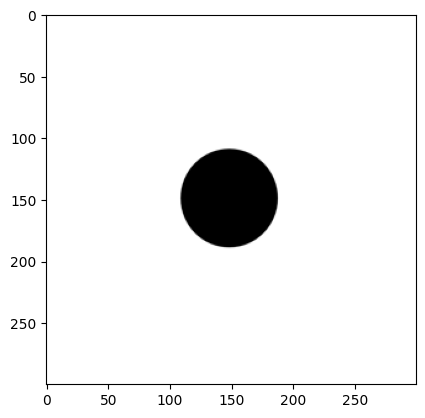

In [7]:
img_width = 300
img_height = 300

dot = PIL.Image.open(r"C:\Users\BIT\Desktop\q\Coursera\5. Deep Learning and Reinforcement Learning\RF_dot.png")
dot = ImageOps.grayscale(dot)
# dot = PIL.ImageOps.invert(dot)
dot = dot.resize((img_width, img_height))
plt.imshow(dot, cmap="gray")
plt.show()

Below, we define the kernel and bias weights. For this section, we chose to use the average kernel, which takes the mean of the pixels. Also, we will use the helper function ```calc_rf``` defined previously to determine the ERF size of a feature in each layer.


In [8]:
kernel = (1/9)*np.ones((3,3,1,1))
b = np.array([0.0])

### Model 1: No Stride
To begin, we'll check what the output looks like when we have a model with no stride. With the parameters specified, our ERF should be 3 for the output.


In [9]:
# Construct the model with no stride
model1 = Sequential()

model1.add(Conv2D(input_shape = (img_width, img_height, 1),
                 filters=1, 
                 kernel_size=(3,3)
                 ))

model1.layers[0].set_weights([kernel,b])

calc_rf(model1)

c:\Users\BIT\Desktop\q\Coursera\5. Deep Learning and Reinforcement Learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layer 1: conv2d 
 Jump Size: 1
 Effective Receptive Field Size: 3
------


### Model 2: Increased Stride


Here we set the ```strides``` to 2 for the 2nd model.


In [10]:
# Construct the model with stride = 2
model2 = Sequential()

model2.add(Conv2D(input_shape = (img_width, img_height, 1),
                 filters=1, 
                 kernel_size=(3,3), 
                 padding='same',
                 strides=2
                 ))

model2.layers[0].set_weights([kernel,b])

calc_rf(model2)

Layer 1: conv2d_1 
 Jump Size: 2
 Effective Receptive Field Size: 3
------


Even with increased stride size, the ERF size is still 3. This is expected because our output's ERF size depends on the kernel and the input's RF and jump, all of which haven't changed between model 1 and 2. 


### Model 3: Increased Layers


Lets see what happens with we increased the number of layers:


In [11]:
# Construct the model with multiple layers
model3 = Sequential()

model3.add(Conv2D(input_shape = (img_width, img_height, 1),
                 filters=1, 
                 kernel_size=(3,3)
                 ))
model3.add(Conv2D(filters=1, 
                 kernel_size=(3,3), 
                 strides=4
                 ))
model3.add(Conv2D(filters=1, 
                 kernel_size=(3,3), 
                 strides=5
                 ))

model3.layers[0].set_weights([kernel,b])
model3.layers[1].set_weights([kernel,b])
model3.layers[2].set_weights([kernel,b])

calc_rf(model3)

Layer 1: conv2d_2 
 Jump Size: 1
 Effective Receptive Field Size: 3
------
Layer 2: conv2d_3 
 Jump Size: 4
 Effective Receptive Field Size: 5
------
Layer 3: conv2d_4 
 Jump Size: 20
 Effective Receptive Field Size: 13
------


After adding more layers to the model, we clearly see the ERF size for each feature increased in subsequent layers. In particular, the ERF of layer 3 is significantly bigger than it would have been if there's no stride.


### Visualizing the Outputs


Let's compare the results to of the models:


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


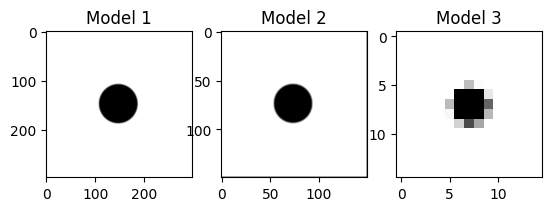

In [12]:
models = [model1, model2, model3]
dot_tensor = np.array(dot).reshape((1,img_width,img_height,1))
fig, ax = plt.subplots(1,len(models))

for i in range(len(models)):
    plt.subplot(1,len(models),i+1)
    output = models[i].predict(dot_tensor)
    output = output.reshape(output.shape[1],output.shape[2])
    plt.title("Model {}".format(i+1))
    plt.imshow(output, cmap='gray')

As we increase the receptive field the subsequent images get smaller and smaller, but we can still make out the shape. This also decreased the number of parameters needed in the model.


## Varied Input-Output Relationships


We previously only dealt with applying one kernel on one channel at a time, but that is quite inefficient to do since we often have access to multichannel (colored) image inputs, whose information can be learned jointly. Moreover, the convolutional layers are analogous to the hidden neurons in a neural network, and like a regular neural network, adding more neurons will improve results. Next, we will take a look at how increasing the number of channels can increase the information extracted.


Consider the following image:


In [ ]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/channel_image.jpg"

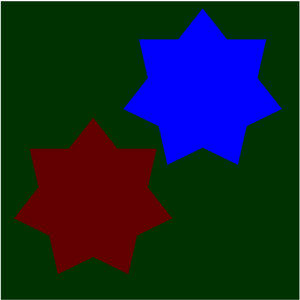

In [13]:
img_width = 300
img_height = 300

image = PIL.Image.open(r"C:\Users\BIT\Desktop\q\Coursera\5. Deep Learning and Reinforcement Learning\channel_image.jpg").resize((img_width, img_height))
image

First, we define two filters we will use throughout the examples. The first filter is an edge kernel, which you have seen previously in the lab on padding, strides, and activation. This kernel helps us detect edges in the image. The second filter is a kernel that sharpens the image through creating greater contrast. Note that usually, in CNN, we would let the network learn the best filters automatically instead of defining them.


In [14]:
def edge_grad(shape, dtype=None):
    grad = np.array([
        [-1, -1, -1],
        [-1, 8, -1],
        [-1, -1, -1]
        ]).reshape(shape)
    
    return grad

def sharpen_grad(shape, dtype=None):
    grad = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ]).reshape(shape)
    
    return grad

### Single Input, Multiple Outputs


Based on what you learned from past labs, you know how to apply a filter on a black and white image, so let's start with that. However, this time we will apply multiple filters on the grayscale image. 


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/SingleInMultiOut.png" width="600" alt="single input multiple output calculation">
<center>


The visual above, shows how outputs are calculated when there is a single channel but multiple filters. We can see that the depth of the output (number of channels it has) corresponds to the number of filters applied on the input. 


Here's a formula for calculating the width/height of one output channel:
$$n_{out} = \frac{n_{in} + 2p - k}{s} + 1$$

- $n_{out}$: width/height of output map
- $n_{in}$: width/height of input map
- $p$: convolution padding size
- $k$: convolution kernel width/height
- $s$: convolution stride size


As a first step, we convert the image to grayscale such that we work with a single channel as our input for now. Here, when the image is converted to grayscale, the stars are not visible anymore due to their RGB values being converted to a singular value representing brightness, which raises the concern of whether the filters will be able to detect any features.


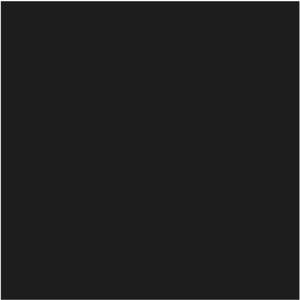

In [15]:
gray = ImageOps.grayscale(image)
img_tensor = np.array(gray).reshape((1, img_width, img_height, 1)) # Convert to a tensor for model prediction
gray

Next, we define the desired kernels. Note here that the kernel takes on the size 3x3x1x2. This means that there are 2 filters, each with the dimension 3x3x1, where 1 represents the number of channels and 3x3 is the 2D kernel size. This shape is required because we are performing both convolutions in a single layer. The bias, set to 0 for both convolutions on the input, is represented by the variable `b`.


In [16]:
kernels = np.array([sharpen_grad((3,3,1,1)), edge_grad((3,3,1,1))])
kernels = kernels.reshape((3,3,1,2))
b = np.array([np.array([0.0]),np.array([0.0])]).reshape(2,)

Here, we define the Sequential model, adding one convolutional layer with 2 filters of size 3x3. After this, we specify the kernels and biases by the function `set_weights`. To see more information about the model built, use `summary()`.


In [21]:

from keras import Input

model = Sequential([
    Input(shape=(300,300,1)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(10)
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 298, 298, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 710432)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     7,104,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,104,650 (27.10 MB)

 Trainable params: 7,104,650 (27.10 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.inputs

[<KerasTensor shape=(None, 300, 300, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>]

In order to see how each filter is applied on the input, we use an additional model that specifies the desired output when given input from our previous model.


In [26]:
layer_outputs = [layer.output for layer in model.layers] # Extracts the outputs of the layer
activation_model = Model(inputs=model.inputs, outputs=layer_outputs) # Creates a model that will return these outputs, given the model input

activation_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 300, 300, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 298, 298, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 710432)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     7,104,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,104,650 (27.10 MB)

 Trainable params: 7,104,650 (27.10 MB)

 Non-trainable params: 0 (0.00 B)

Now that we have set up the model structure, we feed the image tensor as input to the activation model to separate the outputs from individual kernels.


In [27]:
activations = activation_model.predict(img_tensor) # Obtain the outputs (activations) from our model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


In [31]:
import numpy as np

# Remove the batch dimension
filter_outputs = np.squeeze(activations[0])

print(filter_outputs.shape)

(298, 298, 32)


The output shape confirms that the model correctly applied the two filters on the input as the output depth is 2 - one dimension for each filter. Using the formula above, we also know that the width and height are (1)*300+2(1)-3 + 1 = 300. Since each filter output is a tensor, we can also display their weights by directly indexing the object:


In [29]:
# Display weights of the first filter of this layer
filter_outputs[:,:,0]

array([[[48.851025  ,  2.854257  , 39.480415  , ..., 40.703396  ,
         29.5256    ,  4.876944  ],
        [51.681965  , -0.        , 23.239435  , ..., 36.089725  ,
         37.968124  ,  2.0468233 ],
        [54.37793   , -0.        , 15.983756  , ..., 33.992805  ,
         43.09243   ,  0.42455631],
        ...,
        [53.914978  , -0.        , 16.457403  , ..., 34.142754  ,
         42.980247  ,  0.21853828],
        [53.666595  , -0.        , 16.603292  , ..., 34.58175   ,
         42.987003  , -0.        ],
        [59.44035   , -0.        , 12.77467   , ..., 28.461838  ,
         42.597023  ,  4.133012  ]]], shape=(1, 298, 32), dtype=float32)

In [33]:
print("activations[0] shape:", activations[0].shape)

filter_outputs = np.squeeze(activations[0])

print("filter_outputs shape:", filter_outputs.shape)

activations[0] shape: (1, 298, 298, 32)
filter_outputs shape: (298, 298, 32)


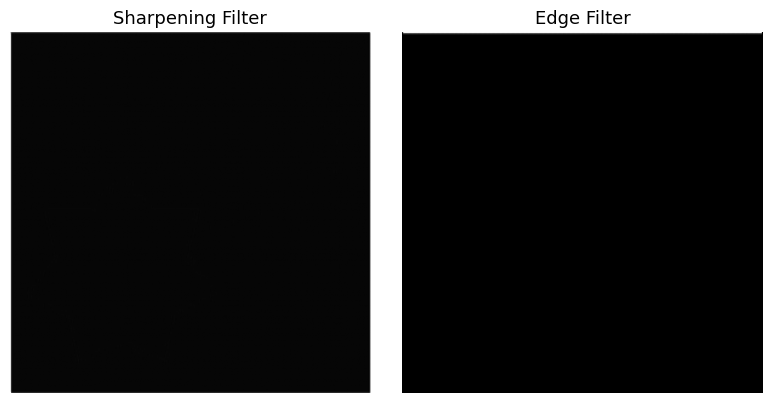

In [34]:
import matplotlib.pyplot as plt

names = ["Sharpening Filter", "Edge Filter"]

plt.figure(figsize=(8,4))

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(filter_outputs[:, :, i], cmap="gray")
    plt.axis("off")
    plt.title(names[i], fontsize=13)

plt.tight_layout()
plt.show()

We can also visualize the outputs from each convolution:


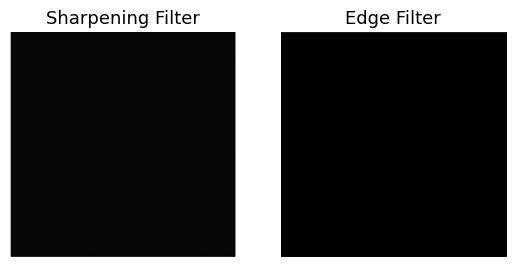

In [32]:
# Display the filter outputs
import matplotlib.pyplot as plt

names = ["Sharpening Filter", "Edge Filter"]

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(filter_outputs[:, :, i], cmap="gray")
    plt.axis("off")
    plt.title(names[i], fontsize=13)

plt.show()

We see that given a grayscale image in which the shapes blended in completely with the background, the sharpening and edge filters can't detect any features that were apparent in the colored image.


### Multiple Inputs, Single Output


So, what if we used a colored image instead? Will the network be better at sharpening the image? Before moving onto utilizing multiple filters, let's see how the output is calculated when we have one filter applied on multiple channels, such as RGB.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/images/MultiInSingleOut.png" width="600" alt="multiple input single output calculation">
<center>


How a filter is applied on multi-channel input is quite similar to the single channel case. What's different is that now, the depth of the filter will correspond to the number of input channels, so one 2D kernel is designated for one channel. The convolved result for each channel is then added together to form a single output channel.


#### Exercise: Reshape the Image


In [ ]:
# Using the RGB image from before, convert it to a numpy array
# and reshape it to be 300x300x3, where 3 is for the three channels.
# WRITE YOUR CODE HERE
img_tensor = np.array(image).reshape((1, img_width, img_height, 3))

: 

<details><summary>Solution</summary>
    <code>img_tensor = np.array(image).reshape((1, img_width, img_height, 3))</code>
</details>


Again, we define the filter we hope to use. In this case, the kernel is of shape 3x3x3x1 because we want one 3x3 filter for each of the 3 input channels. Note that these three filters take on the same value since we want to apply the same convolution on all the channels. With one filter involved for convolution, we specify one bias value.


In [ ]:
kernel = np.array([sharpen_grad((3,3,1,1)), sharpen_grad((3,3,1,1)), sharpen_grad((3,3,1,1))])
kernel = kernel.reshape((3,3,3,1))
b = np.array([0.0])

: 

In [ ]:
model = Sequential()

model.add(Conv2D(filters = 1, 
                 kernel_size = (3, 3), 
                 padding='same', 
                 input_shape = (img_width, img_height, 3)))

model.set_weights([kernel,b])

model.summary()

: 

The output shape for the layer can also be seen in the model summary above. It matches our expectations based on the padding, stride, kernel size, and number of kernels. Again, we can visualize the output result. Since we only have a single filter, we don't need an additional model for separating out the filter outputs. However, we do need to reshape the predicted output into 2D to be able to plot it.


In [ ]:
output = model.predict(img_tensor)
output = output.reshape((img_width, img_height))

: 

In this case, `output` directly shows us the result of applying a filter on the multichannel input.


In [ ]:
# View values of the output tensor
output

: 

In [ ]:
plt.imshow(output, cmap='gray')

: 